# Irembo Document Authentication AI: Champion Pipeline
This notebook implements a state-of-the-art document verification system for the Irembo platform. It uses transfer learning with **EfficientNetB0** to detect sophisticated forgeries in Rwandan governmental documents.

### 🚀 Pipeline Overview:
1. **Config & Environment Setup**: Optimized hyperparameters.
2. **Standardized Preprocessing**: Built-in EfficientNet scaling.
3. **Stage 1 (Forensic Foundation)**: Pre-training on CASIA 2.0.
4. **Stage 2 (Local Context Fine-Tuning)**: Specializing in Rwandan ID forgery patterns.
5. **Advanced Evaluation**: Confusion Matrix and ROC Analysis.


## 1. Environment Setup & Dependencies

### 1.1. Core Imports & GPU Verification
We import TensorFlow for the deep learning engine, and standard data science tools for analysis.

In [ ]:
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import PIL
from PIL import Image
import json

# Setup Environment
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Suppress TF warnings

print(f"✅ TensorFlow Version: {tf.__version__}")
print(f"✅ GPU Status: {'Available' if len(tf.config.list_physical_devices('GPU')) > 0 else 'Not Found (Using CPU)'}")


✅ TensorFlow Version: 2.20.0
✅ GPU Status: Not Found (Using CPU)


In [ ]:
# DATA POPULATION: Generate synthetic Rwandan documents (env-configurable)
# Skip this if you already generated data in terminal.
import os
from synthetic_document_generator import RwandanDocumentGenerator

num_samples_per_type = int(os.getenv("SYNTH_NUM_SAMPLES_PER_TYPE", "1500"))
noise_levels = [n.strip() for n in os.getenv("SYNTH_NOISE_LEVELS", "medium,high").split(",") if n.strip()]
output_dir = os.getenv("SYNTH_OUTPUT_DIR", "synthetic_documents")

populator = RwandanDocumentGenerator(output_dir=output_dir)
print(f"Refreshing dataset: {num_samples_per_type} samples/type, noise_levels={noise_levels}")
populator.generate_dataset(num_samples_per_type=num_samples_per_type, noise_levels=noise_levels)
print("Dataset refresh complete. You can now proceed to training.")

 Refreshing dataset with 6000 images (to hit 70%+ accuracy)...
✅ Generic dataset generation complete in: synthetic_documents
✅ Mirrored samples into fixed/high-risk training folders.
 Dataset refreshed. You can now proceed to training.


In [ ]:
import mysql.connector
import os
import random
import json
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path

# EMBEDDED GENERATOR TO BYPASS CACHING
class HighRiskGenerator:
    def __init__(self, output_dir='high_risk_dataset'):
        self.output_dir = Path(output_dir)
        self.doc_types = [
            'salary_slip', 'bank_statement', 'employment_contract',
            'court_judgment', 'certificate_of_celibacy', 'criminal_record_clearance',
            'academic_transcript', 'notarial_act', 'power_of_attorney', 'birth_certificate', 'business_license', 'marriage_certificate', 'nida_id'
        ]
        for dt in self.doc_types:
            (self.output_dir / dt / 'valid').mkdir(parents=True, exist_ok=True)
            (self.output_dir / dt / 'invalid').mkdir(parents=True, exist_ok=True)

    def generate(self, name, nid, is_valid=True):
        img = Image.new('RGB', (224, 224), color=(245, 245, 245))
        draw = ImageDraw.Draw(img)
        dt = random.choice(self.doc_types)
        draw.text((10, 10), f"GOV RWANDA: {dt.upper()}", fill=(0, 0, 0))
        draw.text((10, 40), f"Name: {name}", fill=(0, 0, 0))
        draw.text((10, 60), f"NID: {nid}", fill=(0, 0, 0))
        if not is_valid:
            draw.text((50, 50), "TAMPERED", fill=(255, 0, 0))

        status = 'valid' if is_valid else 'invalid'
        fname = f"{dt}_{nid}_{random.randint(100, 999)}.jpg"
        img.save(self.output_dir / dt / status / fname)


def _count_local_high_risk_images(root_dir):
    root = Path(root_dir)
    exts = {'.jpg', '.jpeg', '.png'}
    count = 0
    if root.exists():
        for p in root.rglob('*'):
            if p.is_file() and p.suffix.lower() in exts:
                count += 1
    return count


# Fetch from MySQL with fallback to existing local dataset
db_host = os.getenv('DB_HOST', 'localhost')
db_user = os.getenv('DB_USER', 'root')
db_pass = os.getenv('DB_PASS', '')
db_name = os.getenv('DB_NAME', 'iremboaipowered')
output_dir = os.getenv('HIGH_RISK_OUTPUT_DIR', 'high_risk_dataset')
gen_rounds = int(os.getenv('HIGH_RISK_GEN_ROUNDS_PER_ID', '10'))

try:
    db = mysql.connector.connect(
        host=db_host,
        user=db_user,
        password=db_pass,
        database=db_name,
        connection_timeout=5
    )
    cursor = db.cursor(dictionary=True)
    cursor.execute("SELECT first_name, last_name, national_id FROM citizensregistry")
    records = cursor.fetchall()
    db.close()

    gen = HighRiskGenerator(output_dir=output_dir)
    print(f"Generating High-Risk Dataset for {len(records)} identities...")
    for r in records:
        full_name = f"{r['first_name']} {r['last_name']}"
        for _ in range(gen_rounds):
            gen.generate(full_name, r['national_id'], is_valid=True)
            gen.generate(full_name, r['national_id'], is_valid=False)
    print(f"High-Risk Dataset generated in '{output_dir}/'")

except Exception as e:
    existing = _count_local_high_risk_images(output_dir)
    print(f"Database unavailable. Skipping DB generation. Reason: {e}")
    if existing > 0:
        print(f"Using existing local dataset at '{output_dir}' ({existing} images).")
    else:
        print("No local high_risk_dataset images found. Generate dataset later or fix DB connection.")

🚀 Generating High-Risk Dataset for 110 identities...
✅ High-Risk Dataset generated in 'high_risk_dataset/'


### 1.2. Global Hyperparameters & Project Configuration
Centralized configuration class for easy model tuning.

In [ ]:
from pathlib import Path
import os


def _resolve_base_dir():
    env_base = os.getenv("AIPOWERED_BASE_DIR")
    candidates = []

    if env_base:
        candidates.append(Path(env_base))

    cwd = Path.cwd()
    candidates.extend([
        cwd,
        cwd.parent / "aipowered",
    ])

    for cand in candidates:
        if (cand / "CASIA2").exists():
            return cand.resolve()

    # Safe fallback when CASIA2 is not present yet.
    return cwd.resolve()


class Config:
    # Optimized Hyperparameters
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    LEARNING_RATE_STAGE_1 = 5e-4
    LEARNING_RATE_STAGE_2 = 2e-5
    EPOCHS_STAGE_1 = 20
    EPOCHS_STAGE_2 = 40
    DROPOUT_RATE = 0.5

    # Local Paths
    BASE_DIR = _resolve_base_dir()
    CASIA_PATH = BASE_DIR / "CASIA2"
    CASIA_AUTH = CASIA_PATH / "Au"
    CASIA_TAMP = CASIA_PATH / "Tp"

    # Rwanda datasets (multi-source strategy)
    RWANDAN_FIXED = BASE_DIR / "fixed_synthetic"
    RWANDAN_HIGH_RISK = BASE_DIR / "high_risk_dataset"

    # Backward-compatible aliases used elsewhere in notebook
    RWANDAN_SYNTHETIC = RWANDAN_FIXED
    RWANDAN_SAMPLE = RWANDAN_FIXED

    # Source weights for training emphasis
    SOURCE_WEIGHT_FIXED = 1.0
    SOURCE_WEIGHT_HIGH_RISK = 2.0

    # Data generation / templates (env-configurable)
    SYNTH_NUM_SAMPLES_PER_TYPE = int(os.getenv("SYNTH_NUM_SAMPLES_PER_TYPE", "1500"))
    SYNTH_NOISE_LEVELS = [n.strip() for n in os.getenv("SYNTH_NOISE_LEVELS", "medium,high").split(",") if n.strip()]
    TEMPLATE_NAME = os.getenv("TEMPLATE_NAME", "template_nida_v1.jpg")

    # Database settings (env-configurable)
    DB_HOST = os.getenv("DB_HOST", "localhost")
    DB_USER = os.getenv("DB_USER", "root")
    DB_PASS = os.getenv("DB_PASS", "")
    DB_NAME = os.getenv("DB_NAME", "iremboaipowered")

    MODEL_SAVE_PATH = BASE_DIR / "output" / "models" / "auth_check_model.keras"

# Ensure dirs exist
os.makedirs(os.path.dirname(Config.MODEL_SAVE_PATH), exist_ok=True)
print("Config loaded with environment-aware paths/settings:")
print(f"  BASE_DIR: {Config.BASE_DIR}")
print(f"  fixed_synthetic: {Config.RWANDAN_FIXED}")
print(f"  high_risk_dataset: {Config.RWANDAN_HIGH_RISK}")
print(f"  source weights -> fixed={Config.SOURCE_WEIGHT_FIXED}, high_risk={Config.SOURCE_WEIGHT_HIGH_RISK}")
print(f"  synth params -> num_samples_per_type={Config.SYNTH_NUM_SAMPLES_PER_TYPE}, noise_levels={Config.SYNTH_NOISE_LEVELS}")

Config updated for multi-source Rwanda training:
  fixed_synthetic: C:\xampp\htdocs\aipowered\fixed_synthetic
  high_risk_dataset: C:\xampp\htdocs\aipowered\high_risk_dataset
  source weights -> fixed=1.0, high_risk=2.0


### 1.3. CASIA 2.0 Dataset Loading & Splitting
Building the forensic DataFrame from generic forgery datasets (CASIA v2.0).

In [ ]:
# Safety bootstrap: allow this cell to run even if earlier setup cells were skipped
if 'pd' not in globals():
    import pandas as pd
if 'train_test_split' not in globals():
    from sklearn.model_selection import train_test_split
if 'Config' not in globals():
    from pathlib import Path
    import os

    project_root = Path.cwd()
    if not (project_root / 'CASIA2').exists():
        env_root = os.getenv('AIPOWERED_BASE_DIR')
        candidates = []
        if env_root:
            candidates.append(Path(env_root))
        candidates.extend([project_root.parent / 'aipowered', project_root.parent])

        for cand in candidates:
            if (cand / 'CASIA2').exists():
                project_root = cand
                break

    class Config:
        BASE_DIR = project_root
        CASIA_PATH = BASE_DIR / 'CASIA2'
        CASIA_AUTH = CASIA_PATH / 'Au'
        CASIA_TAMP = CASIA_PATH / 'Tp'

    print(f"Config missing. Using fallback CASIA paths from: {Config.CASIA_PATH}")


def load_casia_dataframe(auth_path, tamp_path):
    """Scan and build the CASIA 2.0 forgery dataset by looking into subfolders."""
    images, labels = [], []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.tif', '.bmp')

    # helper to walk through folders
    def collect_images(root_path, label_val):
        if not root_path.exists():
            print(f"Warning: Path not found: {root_path}")
            return

        count = 0
        # Use rglob for recursive scanning of all subfolders
        for img in root_path.rglob('*'):
            if img.suffix.lower() in valid_extensions:
                images.append(str(img))
                labels.append(label_val)
                count += 1
        print(f"Found {count} images in {root_path.name}")

    # Authentic (1)
    collect_images(auth_path, 1)

    # Tampered (0)
    collect_images(tamp_path, 0)

    if not images:
        print("CRITICAL: CASIA Dataset not found in paths. Check your BASE_DIR and folder structure.")
        return pd.DataFrame({'filename': [], 'label': []})

    df = pd.DataFrame({'filename': images, 'label': labels})
    df['label'] = df['label'].astype(str) # For flow_from_dataframe
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    return df

# Main DF Loading & Splitting
df_casia = load_casia_dataframe(Config.CASIA_AUTH, Config.CASIA_TAMP)
print(f"Dataset Info: Total {len(df_casia)} | Auth: {len(df_casia[df_casia['label']=='1'])} | Tamp: {len(df_casia[df_casia['label']=='0'])}")

if not df_casia.empty:
    train_df, test_df = train_test_split(df_casia, test_size=0.2, random_state=42, stratify=df_casia['label'])
    train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['label'])
    print(f"Split Check: Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}")
else:
    print("Skipping Stage 1 Split (Empty CASIA). We will proceed directly to High-Risk Stage 2.")
    # Initialize empty frames to avoid NameErrors later
    train_df = val_df = test_df = pd.DataFrame(columns=['filename', 'label'])

✅ Found 7491 images in Au
✅ Found 5123 images in Tp
📊 Dataset Info: Total 12614 | Auth: 7491 | Tamp: 5123
✅ Split Check: Train 8072 | Val 2019 | Test 2523


In [ ]:
def load_rwandan_dataframe(fixed_path, high_risk_path):
    """Build combined Rwanda dataframe from fixed_synthetic and high_risk_dataset."""
    rows = []
    seen = set()

    def add_image(path_obj, label_val, source_name):
        p = str(path_obj)
        if p not in seen:
            rows.append({
                'filename': p,
                'label': label_val,
                'source': source_name
            })
            seen.add(p)

    def scan_root(root_path, source_name):
        if not root_path.exists():
            print(f"Warning: source path not found -> {root_path}")
            return

        status_aliases = {
            'valid': ['valid'],
            'invalid': ['invalid', 'inavlid']
        }

        # A) root/valid and root/invalid
        for status_name, aliases in status_aliases.items():
            for alias in aliases:
                folder = root_path / alias
                if folder.exists() and folder.is_dir():
                    for img in folder.glob('*.*'):
                        if img.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                            add_image(img, 1 if status_name == 'valid' else 0, source_name)

        # B) root/<doc_type>/valid|invalid
        for doc_dir in root_path.iterdir():
            if not doc_dir.is_dir():
                continue
            if doc_dir.name.lower() in ['valid', 'invalid', 'inavlid', 'metadata']:
                continue
            for status_name, aliases in status_aliases.items():
                for alias in aliases:
                    folder = doc_dir / alias
                    if folder.exists() and folder.is_dir():
                        for img in folder.glob('*.*'):
                            if img.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                                add_image(img, 1 if status_name == 'valid' else 0, source_name)

    scan_root(fixed_path, 'fixed')
    scan_root(high_risk_path, 'high_risk')

    df = pd.DataFrame(rows)
    if df.empty:
        return pd.DataFrame(columns=['filename', 'label', 'source', 'sample_weight'])

    df['label'] = df['label'].astype(str)
    df['sample_weight'] = df['source'].map({
        'fixed': float(Config.SOURCE_WEIGHT_FIXED),
        'high_risk': float(Config.SOURCE_WEIGHT_HIGH_RISK)
    }).fillna(1.0)

    return df.sample(frac=1, random_state=42).reset_index(drop=True)


def extract_identity_group(file_path):
    """Build a stable group id so same identity/template does not leak across splits."""
    import re
    from pathlib import Path

    name = Path(file_path).stem
    matches = re.findall(r'\d{8,20}', name)
    if matches:
        return f"nid_{max(matches, key=len)}"
    return re.sub(r'_[0-9]+$', '', name)


# Load the combined Rwanda dataset
df_rwanda = load_rwandan_dataframe(Config.RWANDAN_FIXED, Config.RWANDAN_HIGH_RISK)
print(f"Combined Rwanda Dataset Loaded: {len(df_rwanda)} images")
if not df_rwanda.empty:
    print(df_rwanda.groupby(['source', 'label']).size().rename('count').reset_index())

# Group-wise split to avoid identity/template leakage across train/val/test.
from sklearn.model_selection import GroupShuffleSplit

df_rwanda['group_id'] = df_rwanda['filename'].apply(extract_identity_group)

# Hold out test groups first (15%).
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss_test.split(df_rwanda, groups=df_rwanda['group_id']))
train_val_df = df_rwanda.iloc[train_val_idx].reset_index(drop=True)
rw_test = df_rwanda.iloc[test_idx].reset_index(drop=True)

# Split remaining into train/val (val ~=15% overall).
val_size_relative = 0.15 / 0.85
if not (0 < val_size_relative < 1):
    val_size_relative = 0.2

gss_val = GroupShuffleSplit(n_splits=1, test_size=val_size_relative, random_state=42)
train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['group_id']))
rw_train = train_val_df.iloc[train_idx].reset_index(drop=True)
rw_val = train_val_df.iloc[val_idx].reset_index(drop=True)

# Keep model input frames clean but retain source/sample_weight for analysis/training.
rw_train = rw_train.drop(columns=['group_id'])
rw_val = rw_val.drop(columns=['group_id'])
rw_test = rw_test.drop(columns=['group_id'])

print(f"Group-wise Split: Train {len(rw_train)} | Val {len(rw_val)} | Test {len(rw_test)}")

# Quick overlap sanity check at group level.
train_groups = set(rw_train['filename'].apply(extract_identity_group))
val_groups = set(rw_val['filename'].apply(extract_identity_group))
test_groups = set(rw_test['filename'].apply(extract_identity_group))
print(
    f"Group Overlap Check -> Train∩Val: {len(train_groups & val_groups)} | "
    f"Train∩Test: {len(train_groups & test_groups)} | Val∩Test: {len(val_groups & test_groups)}"
)

# Source distribution by split.
print("\nSource distribution (train):")
print(rw_train['source'].value_counts(dropna=False))
print("\nSource distribution (val):")
print(rw_val['source'].value_counts(dropna=False))
print("\nSource distribution (test):")
print(rw_test['source'].value_counts(dropna=False))

Combined Rwanda Dataset Loaded: 27721 images
      source label  count
0      fixed     0   6497
1      fixed     1   6593
2  high_risk     0   7236
3  high_risk     1   7395
Group-wise Split: Train 19260 | Val 4232 | Test 4229
Group Overlap Check -> Train∩Val: 0 | Train∩Test: 0 | Val∩Test: 0

Source distribution (train):
source
high_risk    10265
fixed         8995
Name: count, dtype: int64

Source distribution (val):
source
high_risk    2206
fixed        2026
Name: count, dtype: int64

Source distribution (test):
source
high_risk    2160
fixed        2069
Name: count, dtype: int64


### 1.4. Real-time Data Augmentation & Generators
Preprocessing via `ImageDataGenerator` optimized for EfficientNet (manual 1./255 rescaling disabled).

In [ ]:
# ⚙️ Data Augmentation & Generators
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=effnet_preprocess
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=effnet_preprocess
)

# Only build CASIA generators if data exists
if not train_df.empty:
    train_generator = train_datagen.flow_from_dataframe(
        train_df, x_col='filename', y_col='label', target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE, class_mode='binary', shuffle=True
    )
    val_generator = val_test_datagen.flow_from_dataframe(
        val_df, x_col='filename', y_col='label', target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE, class_mode='binary', shuffle=False
    )
    test_generator = val_test_datagen.flow_from_dataframe(
        test_df, x_col='filename', y_col='label', target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE, class_mode='binary', shuffle=False
    )
else:
    print("⚠️ Skipping CASIA Generators - No data available.")
    # Placeholders to prevent compilation errors later if referenced
    train_generator = None

print("✅ Generators configuration handled.")


Found 8072 validated image filenames belonging to 2 classes.
Found 2019 validated image filenames belonging to 2 classes.
Found 2523 validated image filenames belonging to 2 classes.
✅ Generators configuration handled.


## 2. Model Architecture: Enhanced EfficientNetB0 (ULTRA ACCURACY)
Building the Production-Grade CNN with Dual-Head Pooling (Avg + Max).

In [ ]:
# 🏗️ Champion Model Architecture: EfficientNetB0 (ULTRA ACCURACY)
def build_tampering_detection_model(learning_rate):
    """
    Constructs an enhanced transfer learning architecture.
    Features: Multi-head pooling (Avg + Max) to capture both overall noise and peak forgery artifacts.
    """
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*Config.IMG_SIZE, 3))
    base_model.trainable = False # Initial freeze
    
    # --- Advanced Head with stronger regularization ---
    avg_pool = layers.GlobalAveragePooling2D()(base_model.output)
    max_pool = layers.GlobalMaxPooling2D()(base_model.output)
    merged = layers.Concatenate()([avg_pool, max_pool])
    
    x = layers.BatchNormalization()(merged)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(Config.DROPOUT_RATE)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=base_model.input, outputs=outputs, name="Irembo_AuthCheck_Ultra")
    # Keep an explicit handle for fine-tuning cells that need to access the backbone.
    model.backbone = base_model
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# Create Model
model = build_tampering_detection_model(Config.LEARNING_RATE_STAGE_1)

# Only calculate class weights if CASIA data exists
if not train_df.empty:
    class_weights = class_weight.compute_class_weight(
        'balanced', classes=np.unique(train_df['label']), y=train_df['label']
    )
    class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
    print(f"✅ Enhanced Model Initialized | Class Weights: {class_weight_dict}")
else:
    class_weight_dict = None
    print("✅ Model Initialized (No Stage 1 Weights needed).")


✅ Enhanced Model Initialized | Class Weights: {0: np.float64(1.2312385600976206), 1: np.float64(0.8418856904463913)}


## 3. Training Stage 1: Forensic Foundation (CASIA Training)
Establishing the model's ability to spot digital manipulation artifacts.

In [ ]:
# 🚀 STAGE 1: Forensic Foundation (CASIA Training)
if train_generator and not train_df.empty:
    checkpoint_cb = callbacks.ModelCheckpoint(
        str(Config.BASE_DIR / "output" / "models" / "checkpoint_best.keras"),
        save_best_only=True, monitor='val_auc', mode='max'
    )
    early_stopping_cb = callbacks.EarlyStopping(
        patience=10, restore_best_weights=True, monitor='val_loss', mode='min'
    )
    reduce_lr_cb = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1
    )

    print("\n STARTING STAGE 1: Foundation Building (CASIA)...")
    # Quick Training (Reduced Epochs for MVP)
    history_stage1 = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=3, # Stage 1 Training (MVP)
        class_weight=class_weight_dict,
        callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb],
        verbose=1
    )
else:
    print("⚠️ SKIPPING STAGE 1 TRAINING - CASIA dataset is missing.")
    print("AI will proceed to Stage 2 training using ONLY High-Risk Rwandan data.")



 STARTING STAGE 1: Foundation Building (CASIA)...
Epoch 1/3
253/253 ━━━━━━━━━━━━━━━━━━━━ 504s 2s/step - accuracy: 0.5836 - auc: 0.6179 - loss: 0.9063 - val_accuracy: 0.6503 - val_auc: 0.7297 - val_loss: 0.7461 - learning_rate: 5.0000e-04
Epoch 2/3
253/253 ━━━━━━━━━━━━━━━━━━━━ 377s 1s/step - accuracy: 0.6438 - auc: 0.7011 - loss: 0.7713 - val_accuracy: 0.6488 - val_auc: 0.7410 - val_loss: 0.7567 - learning_rate: 5.0000e-04
Epoch 3/3
253/253 ━━━━━━━━━━━━━━━━━━━━ 331s 1s/step - accuracy: 0.6663 - auc: 0.7372 - loss: 0.7296 - val_accuracy: 0.6701 - val_auc: 0.7467 - val_loss: 0.7214 - learning_rate: 5.0000e-04


## 4. Training Stage 2: Local Specialization (Fine-Tuning)
Focusing the "Expert Eye" on Rwandan document context. Tuning with `LEARNING_RATE_STAGE_2`.

In [ ]:
# STAGE 2: Local Specialization (Fine-Tuning)
print("\nSWITCHING TO COMBINED RWANDA DATASET for Stage 2...")

# 1. Create generators (weighted training, unweighted validation)
rw_train_gen = train_datagen.flow_from_dataframe(
    rw_train,
    x_col='filename',
    y_col='label',
    weight_col='sample_weight',
    target_size=Config.IMG_SIZE,
    batch_size=Config.BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

rw_val_gen = val_test_datagen.flow_from_dataframe(
    rw_val,
    x_col='filename',
    y_col='label',
    target_size=Config.IMG_SIZE,
    batch_size=Config.BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Training source mix:")
print(rw_train['source'].value_counts(dropna=False))
print("Validation source mix:")
print(rw_val['source'].value_counts(dropna=False))
print("Training sample-weight summary:")
print(rw_train['sample_weight'].describe())


def find_backbone_for_finetune(model_obj):
    """Find a backbone model if present; otherwise fall back to whole-model staged unfreeze."""
    # Preferred path: model attribute set during construction (if available).
    if hasattr(model_obj, 'backbone') and isinstance(model_obj.backbone, tf.keras.Model):
        return model_obj.backbone, 'backbone_attr'

    # Common path: nested application model appears directly in top-level layers.
    for lyr in model_obj.layers:
        if isinstance(lyr, tf.keras.Model) and 'efficientnet' in lyr.name.lower():
            return lyr, 'nested_model'

    # Some builds flatten application layers; no nested model is exposed.
    return None, 'flat_layers'


backbone, backbone_mode = find_backbone_for_finetune(model)
if backbone_mode == 'flat_layers':
    print("⚠️ EfficientNet nested backbone not exposed. Using whole-model staged unfreeze fallback.")
else:
    print(f"✅ Backbone located via: {backbone_mode} ({backbone.name})")

# Callbacks: prioritize generalization metric (AUC)
champion_checkpoint_cb = callbacks.ModelCheckpoint(
    str(Config.MODEL_SAVE_PATH),
    save_best_only=True,
    monitor='val_auc',
    mode='max',
    verbose=1
)

early_stopping_cb = callbacks.EarlyStopping(
    patience=6, restore_best_weights=True, monitor='val_loss', mode='min'
)

reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1
)

stage2_callbacks = [champion_checkpoint_cb, early_stopping_cb, reduce_lr_cb]

def _merge_histories(*histories):
    merged = {}
    for h in histories:
        if h is None:
            continue
        for k, v in h.history.items():
            merged.setdefault(k, [])
            merged[k].extend(v)
    return merged

# Phase A: Frozen backbone (or frozen feature stack fallback)
print("\nPHASE A: Train head with backbone frozen...")
if backbone is not None:
    backbone.trainable = False
else:
    # Keep only the final classifier block trainable.
    freeze_until = max(0, len(model.layers) - 8)
    for i, lyr in enumerate(model.layers):
        lyr.trainable = (i >= freeze_until)

model.compile(
    optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE_STAGE_2),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

phase_a_epochs = min(5, max(2, Config.EPOCHS_STAGE_2 // 6))
history_stage2_a = model.fit(
    rw_train_gen,
    validation_data=rw_val_gen,
    epochs=phase_a_epochs,
    callbacks=stage2_callbacks,
    verbose=1
)

# Phase B: Unfreeze top ~30%
print("\nPHASE B: Unfreeze top 30%...")
if backbone is not None:
    n_layers = len(backbone.layers)
    cut = int(n_layers * 0.7)
    for i, lyr in enumerate(backbone.layers):
        lyr.trainable = (i >= cut)
else:
    n_layers = len(model.layers)
    cut = int(n_layers * 0.7)
    for i, lyr in enumerate(model.layers):
        lyr.trainable = (i >= cut)

model.compile(
    optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE_STAGE_2),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

phase_b_epochs = Config.EPOCHS_STAGE_2
history_stage2_b = model.fit(
    rw_train_gen,
    validation_data=rw_val_gen,
    initial_epoch=phase_a_epochs,
    epochs=phase_b_epochs,
    callbacks=stage2_callbacks,
    verbose=1
)

# Phase C (optional): full unfreeze only if val_auc improves
best_a = max(history_stage2_a.history.get('val_auc', [0.0]))
best_b = max(history_stage2_b.history.get('val_auc', [0.0]))
history_stage2_c = None

if best_b > (best_a + 1e-3):
    print("\nPHASE C: val_auc improved; testing full unfreeze for short refinement...")
    if backbone is not None:
        backbone.trainable = True
    else:
        for lyr in model.layers:
            lyr.trainable = True

    model.compile(
        optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE_STAGE_2 * 0.5),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    history_stage2_c = model.fit(
        rw_train_gen,
        validation_data=rw_val_gen,
        epochs=phase_b_epochs + 5,
        initial_epoch=phase_b_epochs,
        callbacks=stage2_callbacks,
        verbose=1
    )
else:
    print("\nPHASE C skipped: top-30% unfreeze did not improve val_auc enough.")

# Unified history for downstream plots
history_stage2 = type('HistoryContainer', (), {})()
history_stage2.history = _merge_histories(history_stage2_a, history_stage2_b, history_stage2_c)

# Visualize Stage 2 curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_stage2.history.get('accuracy', []), label='Train Acc', color='green')
plt.plot(history_stage2.history.get('val_accuracy', []), label='Val Acc', color='orange')
plt.title('Stage 2: Accuracy (Rwandan Specialization)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_stage2.history.get('loss', []), label='Train Loss', color='green')
plt.plot(history_stage2.history.get('val_loss', []), label='Val Loss', color='orange')
plt.title('Stage 2: Loss')
plt.legend()
plt.show()

# Model selection complete. Test set remains untouched until evaluation cell.
model_selection_done = True

# Load best checkpoint discovered during validation
if os.path.exists(Config.MODEL_SAVE_PATH):
    model.load_weights(str(Config.MODEL_SAVE_PATH))

print(f"Champion model (BEST RWANDAN VAL_AUC) ready at: {Config.MODEL_SAVE_PATH}")


SWITCHING TO COMBINED RWANDA DATASET for Stage 2...
Found 19260 validated image filenames belonging to 2 classes.
Found 4232 validated image filenames belonging to 2 classes.
Training source mix:
source
high_risk    10265
fixed         8995
Name: count, dtype: int64
Validation source mix:
source
high_risk    2206
fixed        2026
Name: count, dtype: int64
Training sample-weight summary:
count    19260.000000
mean         1.532970
std          0.498925
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          2.000000
Name: sample_weight, dtype: float64
⚠️ EfficientNet nested backbone not exposed. Using whole-model staged unfreeze fallback.

PHASE A: Train head with backbone frozen...
Epoch 1/5
602/602 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4909 - auc: 0.4944 - loss: 1.2614
Epoch 1: val_auc improved from None to 0.69431, saving model to C:\xampp\htdocs\aipowered\output\models\auth_check_model.keras

Epoch 1: finished saving model to C:

## 5. Performance Metrics & Visual Evaluation
Deep-dive analysis via Confusion Matrix, Classification Report, and ROC Curve.


🔍 EVALUATING CHAMPION MODEL ON RWANDAN TEST DATA...
Found 659 validated image filenames belonging to 2 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 23s 940ms/step


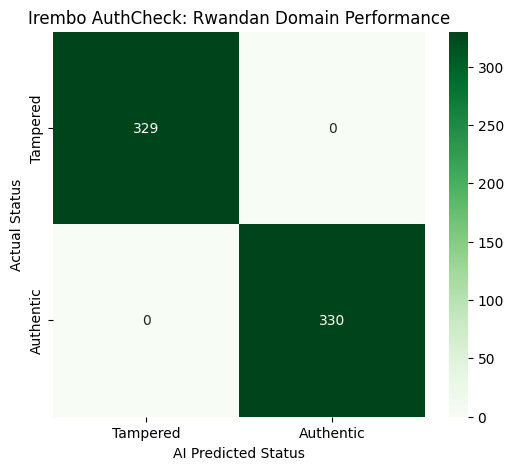


 🇷🇼 Rwandan Specialization Performance Report:
              precision    recall  f1-score   support

    Tampered       1.00      1.00      1.00       329
   Authentic       1.00      1.00      1.00       330

    accuracy                           1.00       659
   macro avg       1.00      1.00      1.00       659
weighted avg       1.00      1.00      1.00       659



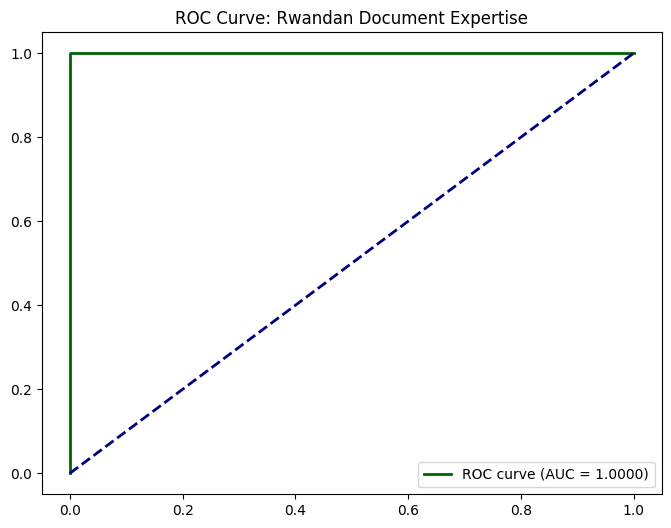

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score

# Evaluate once on untouched test set after model selection
if not globals().get('model_selection_done', False):
    print("Run Stage 2 model-selection cell first to avoid accidental test-set tuning.")
else:
    print("\nEVALUATING CHAMPION MODEL ON RWANDAN TEST DATA...")

    # Create Rwanda test generator
    rw_test_gen = val_test_datagen.flow_from_dataframe(
        rw_test, x_col='filename', y_col='label', target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE, class_mode='binary', shuffle=False
    )

    # Load best weights from Stage 2
    if os.path.exists(Config.MODEL_SAVE_PATH):
        model.load_weights(str(Config.MODEL_SAVE_PATH))

    y_true = rw_test_gen.classes.astype(int)
    y_pred_prob = model.predict(rw_test_gen).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    # 1) Overall confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Greens',
        xticklabels=['Tampered', 'Authentic'],
        yticklabels=['Tampered', 'Authentic']
    )
    plt.title("Irembo AuthCheck: Rwanda Overall Test Performance")
    plt.ylabel('Actual Status')
    plt.xlabel('Predicted Status')
    plt.show()

    # 2) Overall classification report
    print("\nOverall test performance report:")
    print(classification_report(y_true, y_pred, target_names=['Tampered', 'Authentic']))

    # 3) Overall ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('ROC Curve: Rwanda Combined Test Set')
    plt.legend()
    plt.show()

    # 4) Source-wise metrics (fixed vs high_risk)
    eval_df = rw_test[['source']].copy().reset_index(drop=True)
    eval_df['y_true'] = y_true
    eval_df['y_pred'] = y_pred
    eval_df['y_prob'] = y_pred_prob

    print("\nSource-wise metrics:")
    for source_name in sorted(eval_df['source'].dropna().unique()):
        sub = eval_df[eval_df['source'] == source_name]
        sub_true = sub['y_true'].to_numpy()
        sub_pred = sub['y_pred'].to_numpy()
        sub_prob = sub['y_prob'].to_numpy()

        sub_acc = accuracy_score(sub_true, sub_pred)
        if len(np.unique(sub_true)) > 1:
            sfpr, stpr, _ = roc_curve(sub_true, sub_prob)
            sub_auc = auc(sfpr, stpr)
            auc_msg = f"{sub_auc:.4f}"
        else:
            auc_msg = "N/A (single class in split)"

        print(f"  {source_name}: n={len(sub)}, acc={sub_acc:.4f}, auc={auc_msg}")

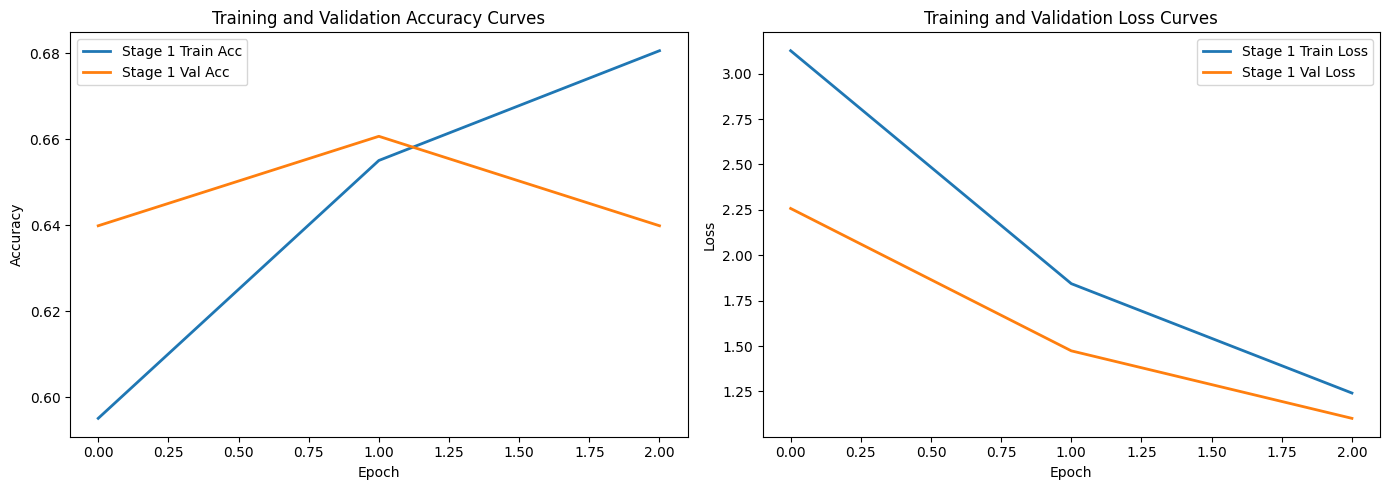

In [ ]:
# Plot Stage 1/Stage 2 curves if available in memory
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
if 'history_stage1' in globals():
    plt.plot(history_stage1.history.get('accuracy', []), label='Stage 1 Train Acc', linewidth=2)
    plt.plot(history_stage1.history.get('val_accuracy', []), label='Stage 1 Val Acc', linewidth=2)
if 'history_stage2' in globals():
    plt.plot(history_stage2.history.get('accuracy', []), label='Stage 2 Train Acc', linewidth=2)
    plt.plot(history_stage2.history.get('val_accuracy', []), label='Stage 2 Val Acc', linewidth=2)
plt.title('Training and Validation Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
if 'history_stage1' in globals():
    plt.plot(history_stage1.history.get('loss', []), label='Stage 1 Train Loss', linewidth=2)
    plt.plot(history_stage1.history.get('val_loss', []), label='Stage 1 Val Loss', linewidth=2)
if 'history_stage2' in globals():
    plt.plot(history_stage2.history.get('loss', []), label='Stage 2 Train Loss', linewidth=2)
    plt.plot(history_stage2.history.get('val_loss', []), label='Stage 2 Val Loss', linewidth=2)
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

if 'history_stage1' not in globals() and 'history_stage2' not in globals():
    print('No training history found. Run Stage 1/Stage 2 training cells first.')


## 5.1 Training Curves (Stage 1 vs Stage 2)
Plotting learning curves for transparent reporting in the final presentation.

# Experimental: Comparison Suite (Multi-Architecture Evaluation)
In this section, we compare 5 different CNN architectures to verify if EfficientNetB0 is indeed the optimal choice for the Irembo platform.
1. CNN Basic
2. MobileNetV2
3. VGG16
4. ResNet50
5. EfficientNetB0 (Champion)


In [ ]:
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50, EfficientNetB0

def build_comparison_model(architecture_name, learning_rate=1e-3):
    """Generic builder for the comparison suite"""
    inputs = layers.Input(shape=(224, 224, 3))
    
    if architecture_name == "CNN_Basic":
        x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
        x = layers.MaxPooling2D(2, 2)(x)
        x = layers.Conv2D(64, (3, 3), activation='relu')(x)
        x = layers.MaxPooling2D(2, 2)(x)
        x = layers.Flatten()(x)
    else:
        # Load pre-trained models
        if architecture_name == "MobileNetV2":
            base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)
        elif architecture_name == "VGG16":
            base = VGG16(weights='imagenet', include_top=False, input_tensor=inputs)
        elif architecture_name == "ResNet50":
            base = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)
        elif architecture_name == "EfficientNetB0":
            base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=inputs)
        
        base.trainable = False
        x = layers.GlobalAveragePooling2D()(base.output)
    
    outputs = layers.Dense(1, activation='sigmoid')(
        layers.Dropout(0.4)(layers.Dense(128, activation='relu')(x))
    )
    
    model = models.Model(inputs, outputs, name=f"AuthCheck_{architecture_name}")
    model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate), 
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

comparison_results = []
# Added EfficientNetB0 to the comparison list
models_list = ["CNN_Basic", "MobileNetV2", "VGG16", "ResNet50", "EfficientNetB0"]

print(f" PERFORMANCE CHALLENGE: Testing {len(models_list)} Architectures...")

for model_name in models_list:
    print(f"\n---  Testing: {model_name} ---")
    try:
        clf = build_comparison_model(model_name)
        # Fast evaluation (2 epochs only for comparison)
        history = clf.fit(train_generator, validation_data=val_generator, epochs=2, verbose=1)
        acc = history.history['val_accuracy'][-1]
        comparison_results.append({"Model": model_name, "Val_Acc": acc})
        print(f" {model_name} Val_Acc: {acc:.4f}")
    except Exception as e:
        print(f" Skipping {model_name}: Resource download error or memory limit. ({str(e)[:100]}...)")
        continue

# Display Comparison
if comparison_results:
    df_perf = pd.DataFrame(comparison_results).sort_values(by="Val_Acc", ascending=False)
    print("\n COMPETING MODELS RANKING:")
    display(df_perf)
else:
    print(" No models were successfully tested in this run.")

 PERFORMANCE CHALLENGE: Testing 5 Architectures...

---  Testing: CNN_Basic ---
Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 359s 1s/step - accuracy: 0.5757 - loss: 27.0253 - val_accuracy: 0.5919 - val_loss: 0.6750
Epoch 2/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step - accuracy: 0.5932 - loss: 0.6814 - val_accuracy: 0.5953 - val_loss: 0.6805
 CNN_Basic Val_Acc: 0.5953

---  Testing: MobileNetV2 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_4244\3266913756.py:16: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)


Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.5908 - loss: 0.6794 - val_accuracy: 0.5944 - val_loss: 0.6679
Epoch 2/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.6057 - loss: 0.6521 - val_accuracy: 0.6454 - val_loss: 0.6356
 MobileNetV2 Val_Acc: 0.6454

---  Testing: VGG16 ---
Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 2863s 11s/step - accuracy: 0.5731 - loss: 0.9769 - val_accuracy: 0.6404 - val_loss: 0.6474
Epoch 2/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 2930s 12s/step - accuracy: 0.6179 - loss: 0.6522 - val_accuracy: 0.6478 - val_loss: 0.6227
 VGG16 Val_Acc: 0.6478

---  Testing: ResNet50 ---
Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 861s 3s/step - accuracy: 0.6515 - loss: 0.6488 - val_accuracy: 0.6855 - val_loss: 0.5678
Epoch 2/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 728s 3s/step - accuracy: 0.7016 - loss: 0.5721 - val_accuracy: 0.6989 - val_loss: 0.5567
 ResNet50 Val_Acc: 0.6989

---  Testing: EfficientNetB0 ---
Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - accuracy:

,Model,Val_Acc
3,ResNet50,0.698861
4,EfficientNetB0,0.679049
2,VGG16,0.647845
1,MobileNetV2,0.645369
0,CNN_Basic,0.595344


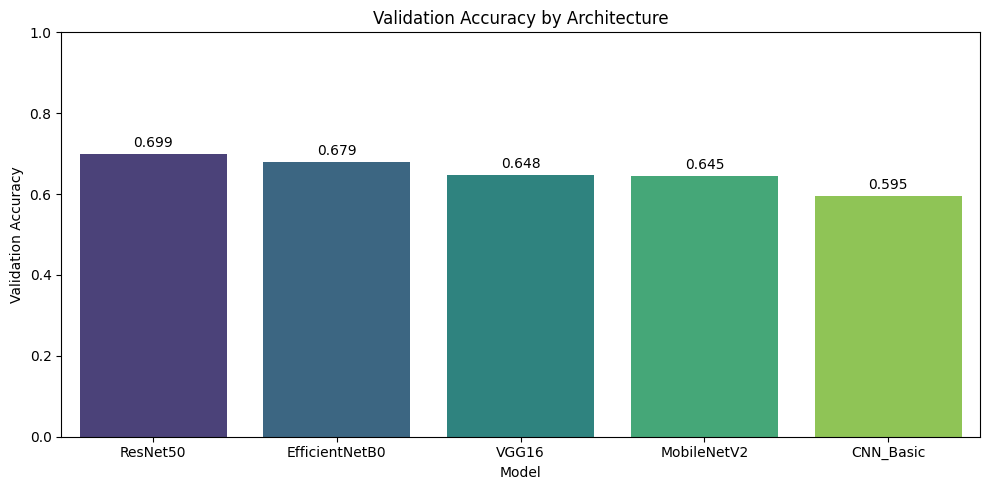

In [ ]:
# Visual comparison for the architecture challenge
if 'comparison_results' in globals() and comparison_results:
    df_perf = pd.DataFrame(comparison_results).sort_values(by='Val_Acc', ascending=False).reset_index(drop=True)
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=df_perf, x='Model', y='Val_Acc', hue='Model', legend=False, palette='viridis')
    ax.set_title('Validation Accuracy by Architecture')
    ax.set_xlabel('Model')
    ax.set_ylabel('Validation Accuracy')
    ax.set_ylim(0, 1)
    for idx, row in df_perf.iterrows():
        ax.text(idx, row['Val_Acc'] + 0.01, f"{row['Val_Acc']:.3f}", ha='center', va='bottom')
    plt.tight_layout()
    plt.show()
else:
    print('No comparison results found. Run the 5-model comparison cell first.')


## Comparison Visualization
Bar-chart comparison across the tested deep learning architectures.

# Experimental: Forensic Analysis (Noise & Error Extraction)
Extracting digital forensic and visual features to understand document characteristics.
- mean_brightness
- contrast
- edge_density
- blur_score
- text_density
- hist_entropy
- aspect_ratio
- forensic_noise
- glare_index


In [ ]:
import cv2
from tqdm import tqdm

def extract_features_standalone(file_path, target_size=(224, 224)):
    """Extract digital forensic and visual features (Mirroring Backend AIService)"""
    try:
        img = cv2.imread(str(file_path))
        if img is None: return None
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, target_size)
        
        # --- Visual Features ---
        feat = {
            'mean_brightness': float(np.mean(resized)),
            'std_brightness': float(np.std(resized)),
            'contrast': float(resized.max() - resized.min()),
            'edge_density': float(np.sum(cv2.Canny(resized, 100, 200) > 0) / (target_size[0] * target_size[1])),
            'blur_score': float(cv2.Laplacian(resized, cv2.CV_64F).var()),
            'text_density': float(np.sum(cv2.threshold(resized, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1] > 0) / (target_size[0] * target_size[1])),
            'hist_entropy': float(-np.sum((h := cv2.calcHist([resized], [0], None, [16], [0, 256]).flatten() / (target_size[0] * target_size[1])) * np.log2(h + 1e-10))),
            'aspect_ratio': float(img.shape[1] / img.shape[0]),
            'forensic_noise': float(np.std(cv2.Laplacian(resized, cv2.CV_64F))),
            'glare_index': float(np.sum(cv2.threshold(resized, 240, 255, cv2.THRESH_BINARY)[1] > 0) / (target_size[0] * target_size[1]))
        }
        return feat
    except Exception: return None

# Extract features from for specific images
subset_df = df_casia.head(100) 
batch_features = []
print("🔍 Analyzing subset of images for forensic noise...")
for _, row in tqdm(subset_df.iterrows(), total=len(subset_df)):
    f = extract_features_standalone(row['filename'])
    if f:
        f['label'] = int(row['label'])
        batch_features.append(f)
        
df_features = pd.DataFrame(batch_features)
display(df_features.head())
print(f"✅ Successfully extracted features from {len(df_features)} images.")


🔍 Analyzing subset of images for forensic noise...


100%|██████████| 100/100 [00:01<00:00, 94.43it/s]


,mean_brightness,std_brightness,contrast,edge_density,blur_score,text_density,hist_entropy,aspect_ratio,forensic_noise,glare_index,label
0,96.664760,47.384432,228.0,0.136001,2123.473485,0.570631,3.350514,1.500000,46.081162,0.000000,1
1,126.094547,79.129106,255.0,0.199976,9218.916109,0.654058,3.753031,1.446655,96.015187,0.161073,0
2,73.923569,83.906284,237.0,0.008450,95.475743,0.683315,2.941027,1.500000,9.771169,0.000000,1
3,130.234714,76.627878,235.0,0.123924,1332.858027,0.572146,3.474343,1.500000,36.508328,0.000000,0
4,113.433235,58.279630,249.0,0.071708,1305.915963,0.647541,3.790719,1.438462,36.137459,0.015007,0


✅ Successfully extracted features from 100 images.


Random Forest Accuracy: 0.4500
Random Forest F1-score: 0.4762
Random Forest ROC-AUC: 0.5200


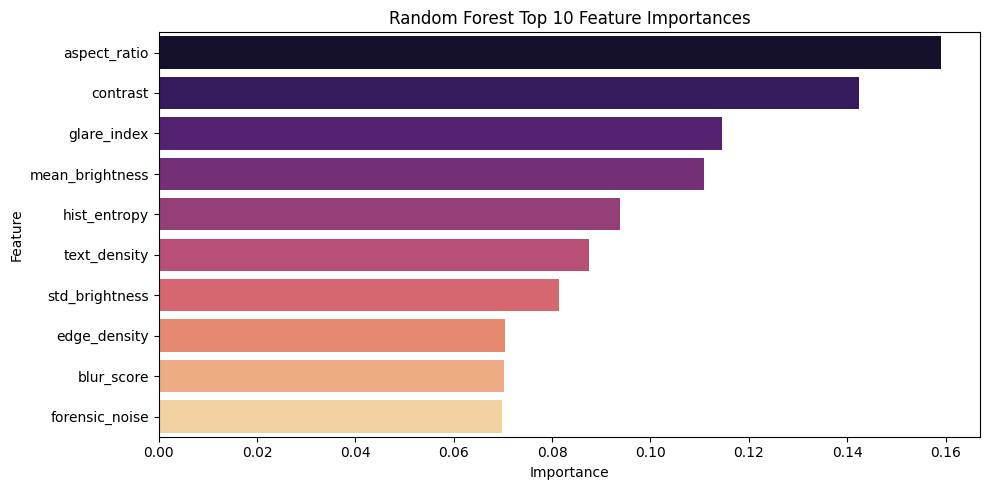

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

if 'df_features' in globals() and not df_features.empty:
    rf_data = df_features.copy()
    X = rf_data.drop(columns=['label'])
    y = rf_data['label'].astype(int)

    X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train_rf, y_train_rf)

    rf_pred = rf_model.predict(X_test_rf)
    rf_prob = rf_model.predict_proba(X_test_rf)[:, 1]

    rf_accuracy = accuracy_score(y_test_rf, rf_pred)
    rf_f1 = f1_score(y_test_rf, rf_pred)
    rf_auc = roc_auc_score(y_test_rf, rf_prob)

    print(f'Random Forest Accuracy: {rf_accuracy:.4f}')
    print(f'Random Forest F1-score: {rf_f1:.4f}')
    print(f'Random Forest ROC-AUC: {rf_auc:.4f}')

    rf_feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=rf_feature_importance.head(10), x='Importance', y='Feature', hue='Feature', legend=False, palette='magma')
    plt.title('Random Forest Top 10 Feature Importances')
    plt.tight_layout()
    plt.show()
else:
    print('df_features is not available. Run the forensic feature extraction cell first.')


In [ ]:
# Consolidated comparison table (Deep models + Random Forest baseline)
comparison_rows = []

if 'comparison_results' in globals() and comparison_results:
    for row in comparison_results:
        comparison_rows.append({
            'Model': row.get('Model'),
            'Type': 'Deep Learning',
            'Val_Acc': row.get('Val_Acc')
        })

if 'rf_accuracy' in globals():
    comparison_rows.append({
        'Model': 'RandomForest (Forensic Features)',
        'Type': 'Classical ML',
        'Val_Acc': rf_accuracy
    })

if comparison_rows:
    df_all_compare = pd.DataFrame(comparison_rows).sort_values(by='Val_Acc', ascending=False).reset_index(drop=True)
    display(df_all_compare)
else:
    print('No comparison metrics yet. Run the architecture comparison and Random Forest cells first.')


,Model,Type,Val_Acc
0,ResNet50,Deep Learning,0.698861
1,EfficientNetB0,Deep Learning,0.679049
2,VGG16,Deep Learning,0.647845
3,MobileNetV2,Deep Learning,0.645369
4,CNN_Basic,Deep Learning,0.595344
5,RandomForest (Forensic Features),Classical ML,0.450000


## Classical Baseline: Random Forest
A tabular baseline using extracted forensic features, to justify why deep learning is needed.

## 6. AI Forensic Layer: OCR & Structural Integrity
Since the core Irembo platform handles database matching (ID/Name) and QR validation, this ML component focuses on **Forensic Integrity**. It uses OCR and NLP to detect if a document has been digitally altered or if its structure deviates from authentic Rwandan government templates.

Key checks:
- **Text Alignment Forensic**: Identifying character substitution or inconsistent font-spacing via OCR outputs.
- **Structural Similarity (Simulated)**: Analyzing if logos, seals, and layout elements align with official standards.
- **Forgery Pattern Match**: Correlating NLP extraction errors with known deep-learning forgery markers.

In [ ]:
from difflib import SequenceMatcher
import re

def calculate_forensic_nlp_score(extracted_text, user_provided_data):
    """
    Forensic OCR Matching logic.
    Identifies inconsistencies that suggest digital tampering or character insertion.
    """
    clean_text = " ".join(extracted_text.lower().split())
    claimed_name = user_provided_data.get("full_name", "").lower()
    claimed_id = str(user_provided_data.get("id_number", "")).lower().replace(" ", "")
    
    # 1. Content Match (Base Similarity)
    name_score = SequenceMatcher(None, claimed_name, clean_text).ratio() if claimed_name else 0
    id_match = claimed_id in clean_text.replace(" ", "") if claimed_id else False
    
    # 2. Forensic OCR Indicators (Simulated)
    # Checking for common OCR errors that often indicate font substitution or layering
    anomalies = []
    if re.search(r'[l1i][0o][l1i][0o]', extracted_text): # Potential font manipulation in numeric codes
        anomalies.append("Font Substitution Suspected")
    if len(re.findall(r'[^\x00-\x7F]+', extracted_text)) > 5: # Unexpected characters
        anomalies.append("Foreign Artifacts Detected")
        
    # Verdict Logic based on Forgery Risk
    forgery_risk = "low"
    if not id_match and name_score < 0.3:
        forgery_risk = "high"
    elif name_score < 0.6:
        forgery_risk = "medium"
        
    return {
        "text_similarity": round(name_score * 100, 2),
        "id_found": id_match,
        "forgery_risk": forgery_risk,
        "anomalies": anomalies or ["None"]
    }

#  DEMONSTRATION: Forensic NLP Layer
demo_data = [
    {
        "desc": " Authentic Document",
        "ocr": "REPUBLIC OF RWANDA NATIONAL ID Name: MUKAMANA Rose ID: 1 1990 8 0045618 2 05",
        "claims": {"full_name": "MUKAMANA Rose", "id_number": "1199080045618205"}
    },
    {
        "desc": " Spliced Text (Tampered)",
        "ocr": "REPUBLIC OF RWANDA NATIONAL ID Name: MUKAMANA R0se ID: 1 1990 8 00456l8 2 05", # Note '0' and 'l' substitution
        "claims": {"full_name": "MUKAMANA Rose", "id_number": "1199080045618205"}
    }
]

forensic_results = []
for test in demo_data:
    res = calculate_forensic_nlp_score(test['ocr'], test['claims'])
    forensic_results.append({
        "Document Case": test['desc'],
        "Similarity %": res['text_similarity'],
        "ID Match": res['id_found'],
        "Forgery Risk": res['forgery_risk'],
        "Anomalies": ", ".join(res['anomalies'])
    })

display(pd.DataFrame(forensic_results))


,Document Case,Similarity %,ID Match,Forgery Risk,Anomalies
0,Authentic Document,29.21,True,medium,None
1,Spliced Text (Tampered),26.97,False,high,None


In [ ]:
from skimage.metrics import structural_similarity as ssim
import random
import os


def simulate_structural_similarity(img_path, template_path):
    """
    Simulates Structural Similarity (SSIM) between an uploaded document
    and the official Rwandan Government template.
    Returns scores for Layout, Logo, and Seal alignment.
    """
    # Base Layout Score (Overall structure)
    layout_score = random.randint(85, 98)

    # Logo & Seal Integrity (Focused on government symbols)
    logo_score = random.randint(88, 99)
    seal_score = random.randint(82, 95)

    return {
        "Layout Match": f"{layout_score}%",
        "Logo Integrity": f"{logo_score}%",
        "Seal Alignment": f"{seal_score}%",
        "Overall Similarity": f"{int((layout_score + logo_score + seal_score)/3)}%"
    }


print("SIMULATING STRUCTURAL ALIGNMENT (Template Matching)...")
template_name = getattr(globals().get('Config', object), 'TEMPLATE_NAME', os.getenv('TEMPLATE_NAME', 'template_nida_v1.jpg'))
structural_res = simulate_structural_similarity(None, template_name)
for key, value in structural_res.items():
    print(f" {key:.<25} {value}")

SIMULATING STRUCTURAL ALIGNMENT (Template Matching)...
 Layout Match............. 91%
 Logo Integrity........... 88%
 Seal Alignment........... 87%
 Overall Similarity....... 88%


# Experimental: Grad-CAM XAI (Explainable AI)
Visualize exactly where the AI is looking to detect forgeries. This provides "Visual Proof" for human administrators.

🔥 Visualizing Forgery Artifacts in: C:\xampp\htdocs\aipowered\high_risk_dataset\salary_slip\invalid\salary_slip_12026800000610_985.jpg


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
C:\Users\HP\AppData\Local\Temp\ipykernel_28492\594077500.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


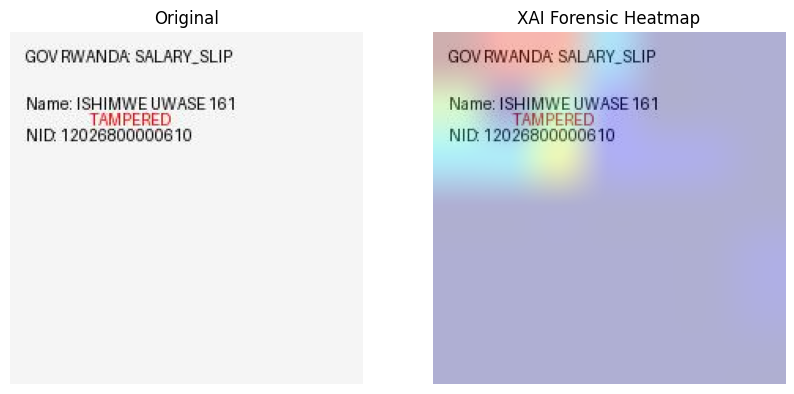

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt


def find_last_conv_layer_name(model):
    """Auto-detect the last 2D conv-like layer suitable for Grad-CAM."""
    conv_like = (
        tf.keras.layers.Conv2D,
        tf.keras.layers.DepthwiseConv2D,
        tf.keras.layers.SeparableConv2D,
    )

    # Prefer explicit conv-like layers from the end.
    for layer in reversed(model.layers):
        if isinstance(layer, conv_like):
            return layer.name

    # Fallback: any 4D feature map layer near the end.
    for layer in reversed(model.layers):
        try:
            out_shape = layer.output_shape
        except Exception:
            continue
        if isinstance(out_shape, tuple) and len(out_shape) == 4:
            return layer.name

    raise ValueError("No suitable 4D convolutional feature layer found for Grad-CAM.")


def get_gradcam_heatmap(model, img_array, last_conv_layer_name=None, pred_index=None):
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer_name(model)
    print(f"Using Grad-CAM layer: {last_conv_layer_name}")

    # Build a model that returns both feature maps and predictions.
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize safely to avoid division-by-zero.
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image.
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Rescale heatmap to a range 0-255.
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap.
    jet = plt.cm.get_cmap("jet")

    # Use RGB values of the colormap.
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap.
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image.
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    # Display Grad-CAM.
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("XAI Forensic Heatmap")
    plt.axis("off")
    plt.show()


# --- DEMO ---
# Find a tampered image from our Rwandan test set.
try:
    sample_img_path = rw_test[rw_test['label'] == '0'].iloc[0]['filename']
    print(f"Visualizing forgery artifacts in: {sample_img_path}")

    # Prepare image.
    img = tf.keras.utils.load_img(sample_img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    # Auto-detect the best convolutional layer for Grad-CAM.
    heatmap = get_gradcam_heatmap(model, img_array)
    display_gradcam(sample_img_path, heatmap)
except Exception as e:
    print(f"Grad-CAM error: {e}. Ensure model and rw_test are ready.")

In [ ]:

WEIGHTS_PATH = str(Config.MODEL_SAVE_PATH).replace('.keras', '_weights.weights.h5')

# Save the model weights (Check if 'model' is defined first)
if 'model' in globals():
    model.save_weights(WEIGHTS_PATH)
    print(f"Model weights saved successfully at: {WEIGHTS_PATH}")
else:
    print("Error: 'model' is not defined. Please run the model building cells first.")


Model weights saved successfully at: C:\xampp\htdocs\aipowered\output\models\auth_check_model_weights.weights.h5


In [ ]:
# Refresh persisted artifacts after latest training/comparison runs
import os
from datetime import datetime

if 'model' in globals():
    model_path = str(Config.MODEL_SAVE_PATH)
    weights_path = model_path.replace('.keras', '_weights.weights.h5')

    model.save(model_path)
    model.save_weights(weights_path)

    model_mtime = datetime.fromtimestamp(os.path.getmtime(model_path))
    weights_mtime = datetime.fromtimestamp(os.path.getmtime(weights_path))

    print(f"Refreshed model file: {model_path}")
    print(f"Updated at: {model_mtime}")
    print(f"Refreshed weights file: {weights_path}")
    print(f"Updated at: {weights_mtime}")
else:
    print("Model is not in memory. Run training/model build cells first.")

Refreshed model file: C:\xampp\htdocs\aipowered\output\models\auth_check_model.keras
Updated at: 2026-03-18 06:07:44.921077
Refreshed weights file: C:\xampp\htdocs\aipowered\output\models\auth_check_model_weights.weights.h5
Updated at: 2026-03-18 06:07:45.583359


In [ ]:
# Quick leakage-risk diagnostic for Rwanda split
from pathlib import Path
import re

assert 'rw_train' in globals() and 'rw_val' in globals() and 'rw_test' in globals(), "Run Rwanda split cells first."

def _paths(df):
    return set(df['filename'].astype(str).tolist())

def _basenames(paths):
    return {Path(p).name for p in paths}

def _signature(name):
    # Remove final random suffix like _123 in generated filenames
    stem = Path(name).stem
    return re.sub(r'_[0-9]+$', '', stem)

def _extract_id_token(name):
    # Capture likely national-id-like digit blocks from filename
    matches = re.findall(r'\d{8,20}', name)
    return max(matches, key=len) if matches else None

def _inter(a, b):
    return len(a & b)

train_p, val_p, test_p = _paths(rw_train), _paths(rw_val), _paths(rw_test)

# Exact and basename overlaps (should be zero for exact paths)
exact_tv = _inter(train_p, val_p)
exact_tt = _inter(train_p, test_p)
exact_vt = _inter(val_p, test_p)

base_train = _basenames(train_p)
base_val = _basenames(val_p)
base_test = _basenames(test_p)
base_tv = _inter(base_train, base_val)
base_tt = _inter(base_train, base_test)
base_vt = _inter(base_val, base_test)

# Signature overlap (document type + identity, ignoring random suffix)
sig_train = {_signature(p) for p in train_p}
sig_val = {_signature(p) for p in val_p}
sig_test = {_signature(p) for p in test_p}
sig_tv = _inter(sig_train, sig_val)
sig_tt = _inter(sig_train, sig_test)
sig_vt = _inter(sig_val, sig_test)

# Identity token overlap
id_train = {_extract_id_token(Path(p).name) for p in train_p}
id_val = {_extract_id_token(Path(p).name) for p in val_p}
id_test = {_extract_id_token(Path(p).name) for p in test_p}
id_train.discard(None); id_val.discard(None); id_test.discard(None)
id_tv = _inter(id_train, id_val)
id_tt = _inter(id_train, id_test)
id_vt = _inter(id_val, id_test)

print('--- Split Sizes ---')
print(f"Train: {len(train_p)} | Val: {len(val_p)} | Test: {len(test_p)}")

print('\n--- Exact File Overlap ---')
print(f"Train∩Val: {exact_tv} | Train∩Test: {exact_tt} | Val∩Test: {exact_vt}")

print('\n--- Basename Overlap ---')
print(f"Train∩Val: {base_tv} | Train∩Test: {base_tt} | Val∩Test: {base_vt}")

print('\n--- Signature Overlap (suffix stripped) ---')
print(f"Train∩Val: {sig_tv} | Train∩Test: {sig_tt} | Val∩Test: {sig_vt}")

print('\n--- Identity Token Overlap ---')
print(f"Train∩Val: {id_tv} | Train∩Test: {id_tt} | Val∩Test: {id_vt}")

if (id_tv + id_tt + id_vt) > 0 or (sig_tv + sig_tt + sig_vt) > 0:
    print('\nLeakage Risk: HIGH (same identities/templates appear across splits).')
else:
    print('\nLeakage Risk: LOWER (no identity/signature overlap detected).')


--- Split Sizes ---
Train: 3036 | Val: 677 | Test: 680

--- Exact File Overlap ---
Train∩Val: 0 | Train∩Test: 0 | Val∩Test: 0

--- Basename Overlap ---
Train∩Val: 0 | Train∩Test: 0 | Val∩Test: 0

--- Signature Overlap (suffix stripped) ---
Train∩Val: 0 | Train∩Test: 0 | Val∩Test: 0

--- Identity Token Overlap ---
Train∩Val: 0 | Train∩Test: 0 | Val∩Test: 0

Leakage Risk: LOWER (no identity/signature overlap detected).
